In [10]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
from scipy.stats import chi2_contingency
from sklearn.feature_selection import mutual_info_classif

In [2]:
features = pd.read_csv('dataset/features.csv')
outcomes = pd.read_csv('dataset/loan_outcomes_train.csv')

In [3]:
df = features.merge(
    outcomes[["user_id", "is_repaid"]],
    on="user_id",
    how="inner"
)

### Multiple features with very high NaN%, cannot do imputation for such high values

In [9]:
df.isna().sum() / len(df) * 100

user_id        0.000000
feature_1     15.045123
feature_2     10.804797
feature_3     62.875510
feature_4     41.426629
feature_5      0.000000
feature_6      0.000000
feature_7     28.136976
feature_8     72.345160
feature_9      0.000000
feature_10     0.000000
is_repaid      0.000000
dtype: float64

### Not trying to do imputation due to high missingness, will try to see if missingness itself is a pattern itself via Hypothesis Testing using Chi-Square Test

Since we have sample distribution we do Chi-Square Test

Null Hypothesis (H0): Missingness in any masked feature is independent of the target outcome(is_repaid).

Alternate Hypothesis (H1): Missingness in any masked feature is dependent of the target outcome(is_repaid).

In [11]:
df['feature_3_is_missing'] = df['feature_3'].isna().astype(int)
df['feature_4_is_missing'] = df['feature_4'].isna().astype(int)
df['feature_7_is_missing'] = df['feature_7'].isna().astype(int)
df['feature_8_is_missing'] = df['feature_8'].isna().astype(int)

In [12]:
# considered features with high missingness
nan_columns = ['feature_3_is_missing', 'feature_4_is_missing', 'feature_7_is_missing', 'feature_8_is_missing']
target = 'is_repaid'

results = []

for col in nan_columns:
    contingency_table = pd.crosstab(df[col], df[target])
    chi2, p, dof, ex = chi2_contingency(contingency_table)
    results.append({
        'Feature': col,
        'Chi2 Statistic': chi2,
        'p-value': p,
        'Significant': p < 0.05
    })

# covnert to df
chi_results_df = pd.DataFrame(results)
print(chi_results_df)

                Feature  Chi2 Statistic   p-value  Significant
0  feature_3_is_missing        4.866547  0.027382         True
1  feature_4_is_missing        0.121790  0.727102        False
2  feature_7_is_missing        0.127629  0.720903        False
3  feature_8_is_missing        0.379741  0.537742        False


### Boxplots and Non-Linearity Check

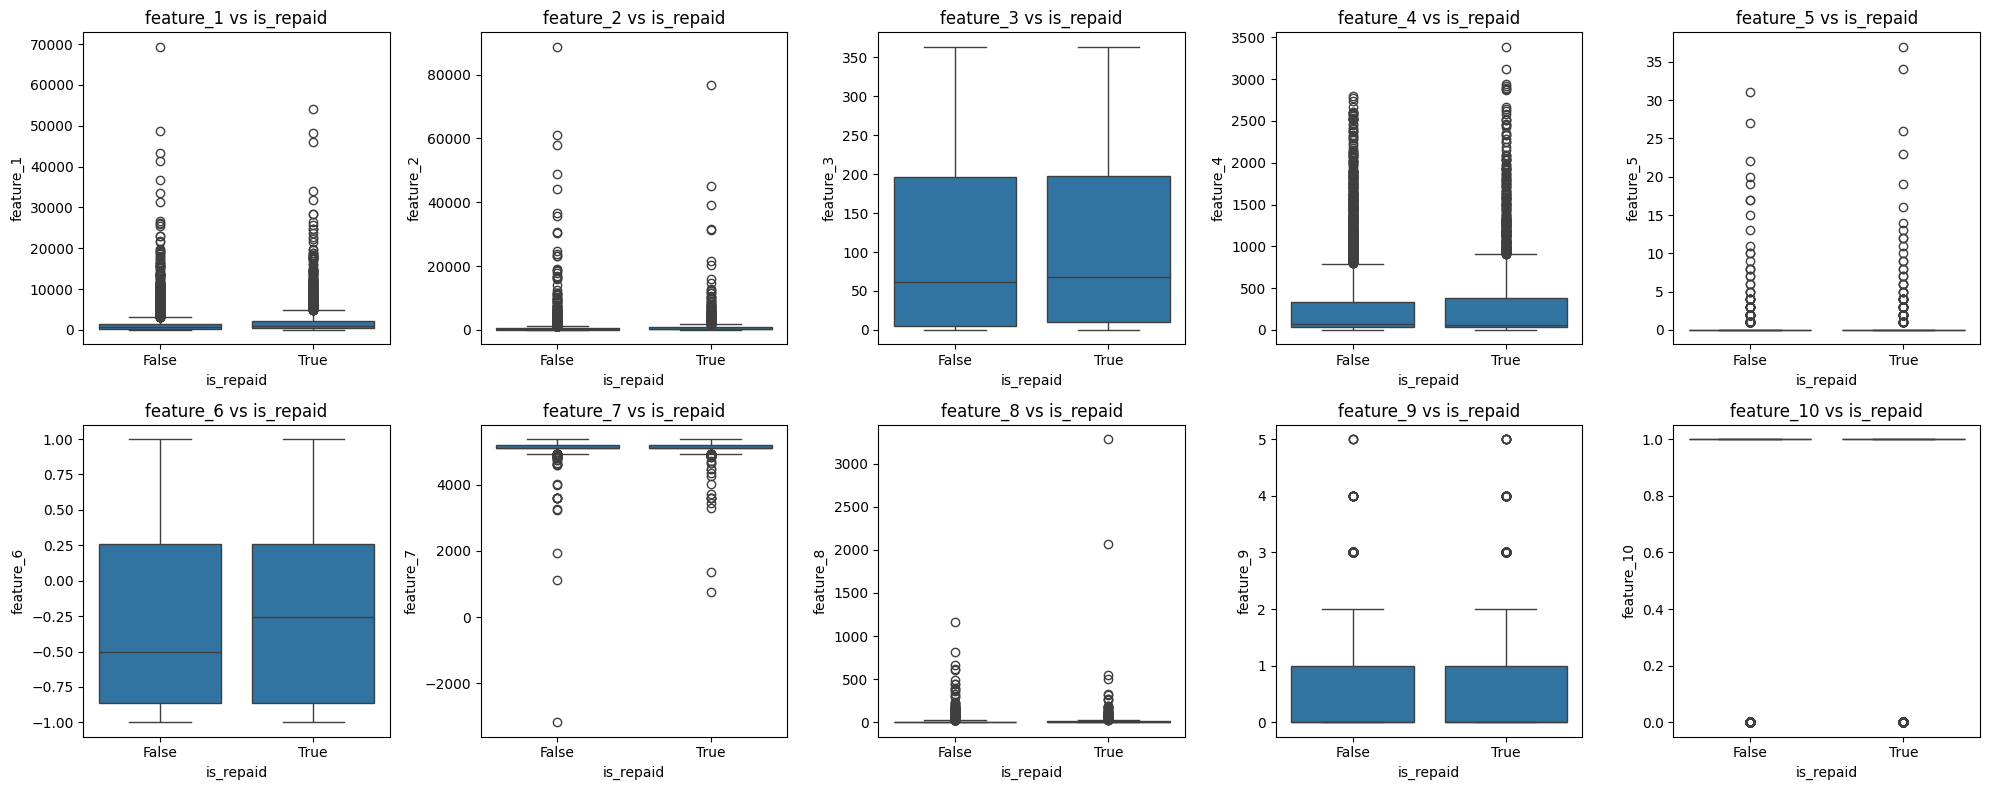

In [5]:
features = [f'feature_{i}' for i in range(1, 11)]
target = 'is_repaid'

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()  # make indexing easier

for i, col in enumerate(features):
    # Drop NaNs only for the current feature
    clean_data = df[[col, target]].dropna()

    sns.boxplot(
        x=target,
        y=col,
        data=clean_data,
        showfliers=True,
        ax=axes[i]
    )

    axes[i].set_title(f'{col} vs {target}')
    axes[i].set_xlabel(target)
    axes[i].set_ylabel(col)

plt.tight_layout()
plt.show()

### KDE plots for Non-Linearity Check

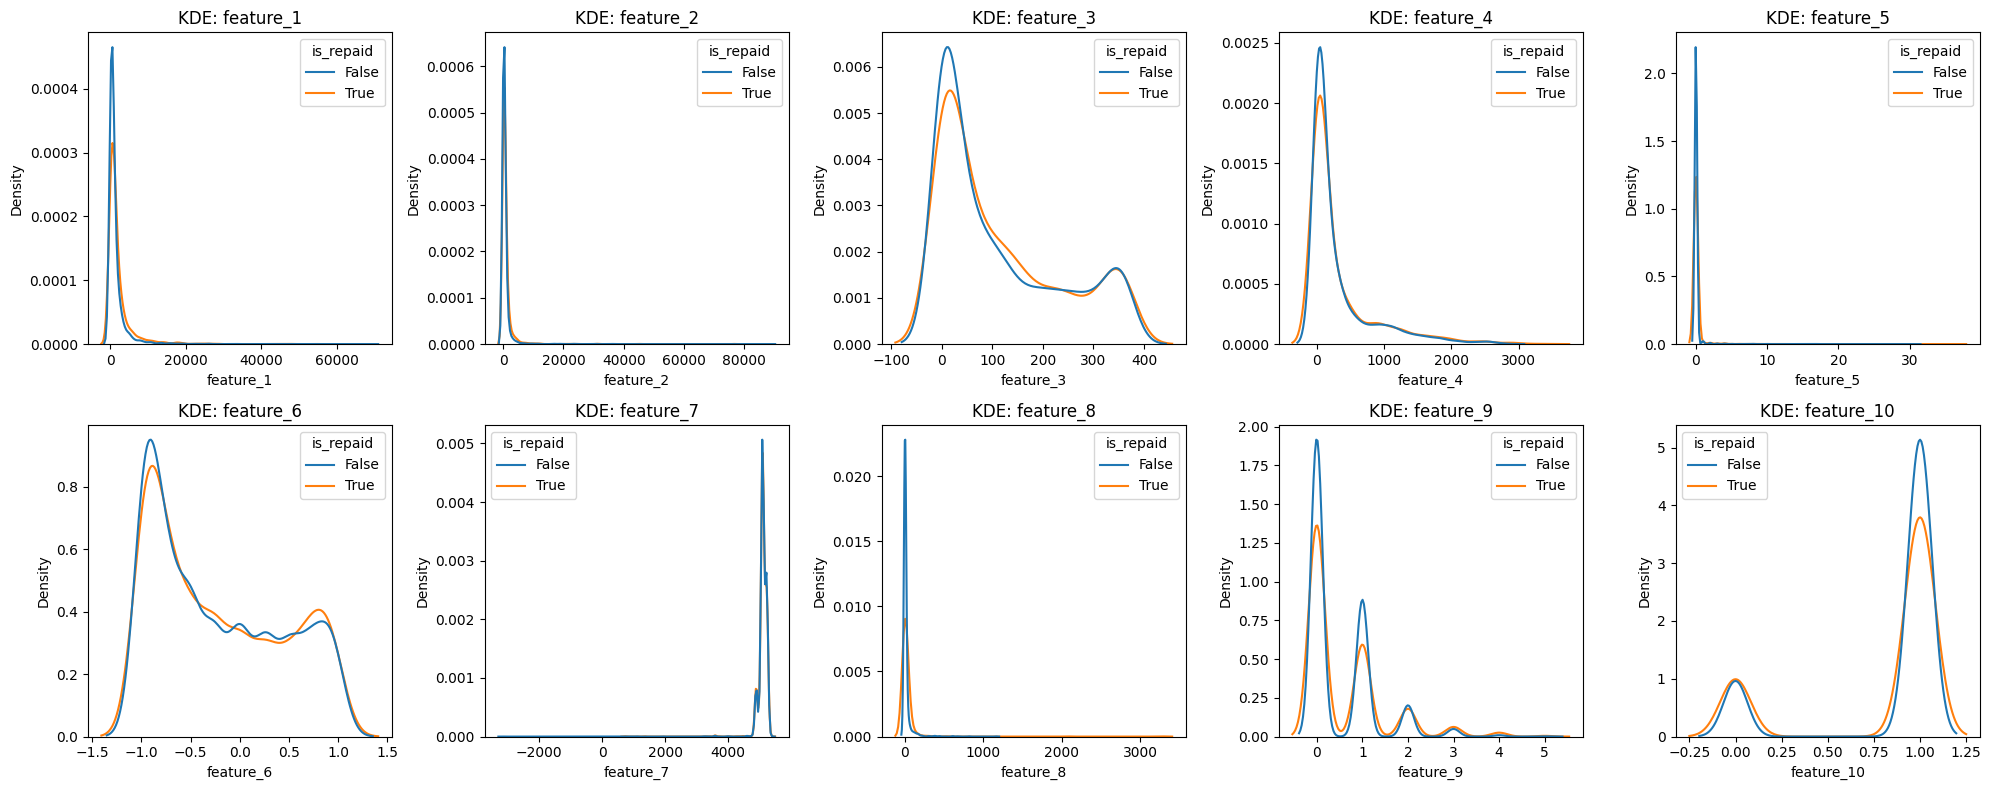

In [6]:
features = [f'feature_{i}' for i in range(1, 11)]
target = 'is_repaid'

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for i, col in enumerate(features):
    sns.kdeplot(
        data=df,
        x=col,
        hue=target,
        common_norm=False,
        ax=axes[i]
    )

    axes[i].set_title(f'KDE: {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Density')

plt.tight_layout()
plt.show()

### Mutual Information and Spearman (just for sake of proving non-linearity) Values, to find redundant features

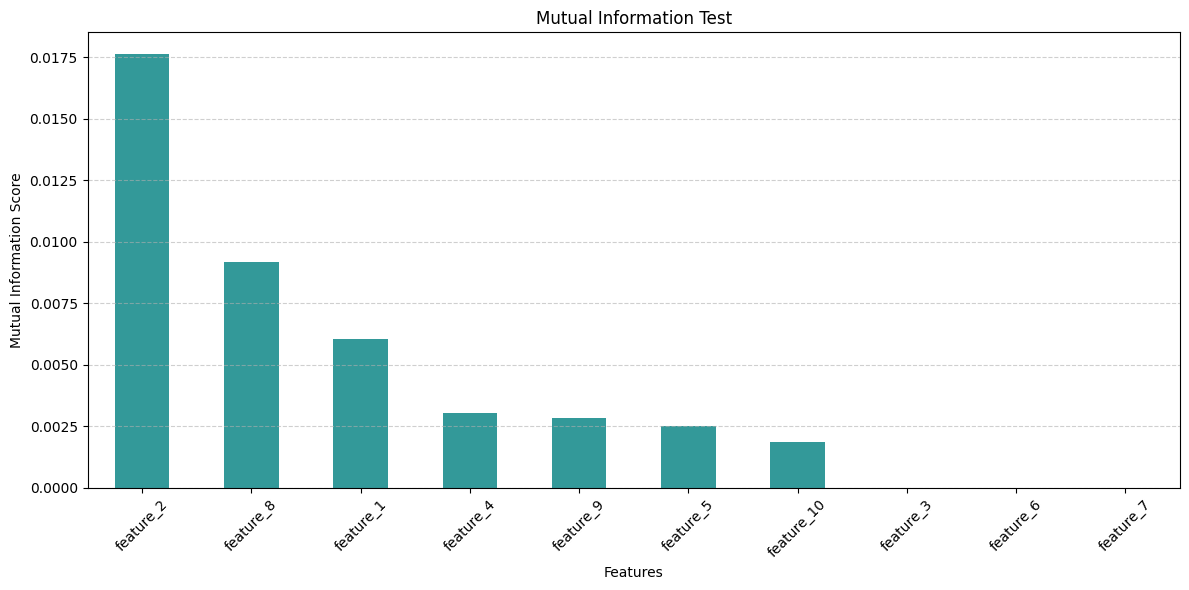

Mutual Information Ranks
feature_2     0.017634
feature_8     0.009174
feature_1     0.006045
feature_4     0.003023
feature_9     0.002833
feature_5     0.002500
feature_10    0.001866
feature_3     0.000000
feature_6     0.000000
feature_7     0.000000
dtype: float64


In [9]:
# apparently there is a param to swtich from continuous to categorical features
features_to_test = [f'feature_{i}' for i in range(1, 11)]
target = 'is_repaid'
categorical_features = {'feature_5', 'feature_9', 'feature_10'}
# dict to store MI results and clean coz dropping NaNs
mi_clean_scores = {}

for col in features_to_test:
    clean_data = df[[col, target]].dropna()
    
    X_clean = clean_data[[col]]
    y_clean = clean_data[target]
    
    is_discrete = col in categorical_features
    
    score = mutual_info_classif(
        X_clean,
        y_clean,
        discrete_features=is_discrete,
        random_state=42
    )[0]
    
    mi_clean_scores[col] = score

# convert to series and sort
mi_clean_results = pd.Series(mi_clean_scores).sort_values(ascending=False)

# vizualisation
plt.figure(figsize=(12, 6))
mi_clean_results.plot(kind='bar', color='teal', alpha=0.8)
plt.title("Mutual Information Test")
plt.ylabel("Mutual Information Score")
plt.xlabel("Features")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

print("Mutual Information Ranks")
print(mi_clean_results)

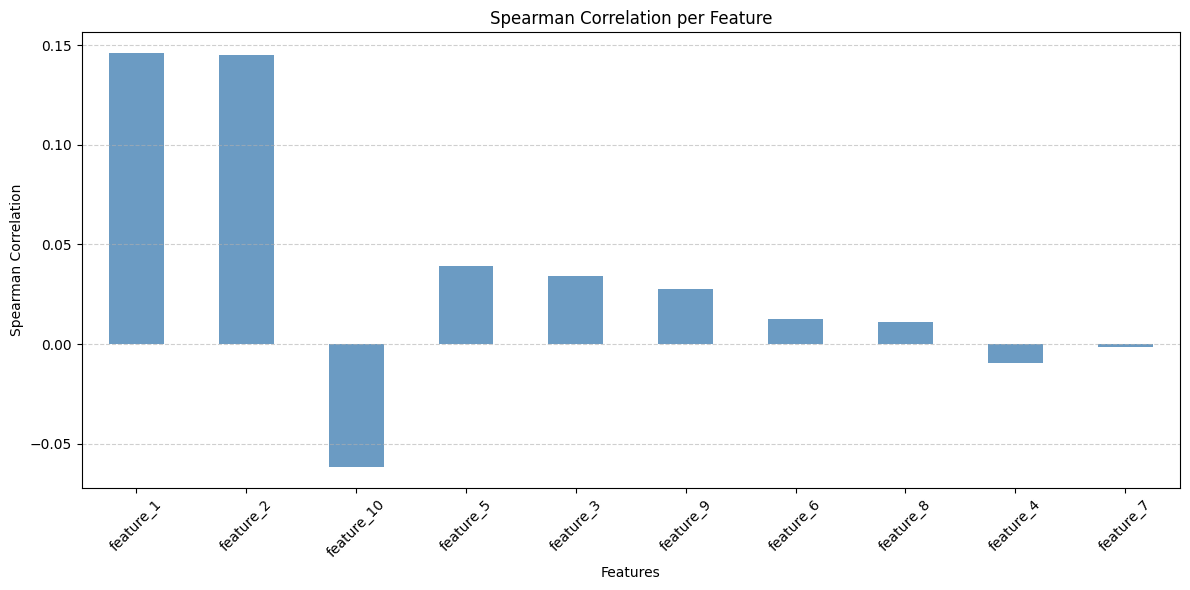

Spearman Correlation Ranks
feature_1     0.146118
feature_2     0.145033
feature_10   -0.061743
feature_5     0.039064
feature_3     0.033933
feature_9     0.027507
feature_6     0.012324
feature_8     0.011225
feature_4    -0.009587
feature_7    -0.001534
dtype: float64


In [13]:
# dict to store Spearman results, same clean approach
spearman_clean_scores = {}

features_to_test = [f'feature_{i}' for i in range(1, 11)]
target = 'is_repaid'

for col in features_to_test:
    clean_data = df[[col, target]].dropna()
    X_clean = clean_data[col]
    y_clean = clean_data[target]

    # returns (correlation, p-value)
    rho, pval = spearmanr(X_clean, y_clean)
    spearman_clean_scores[col] = rho

# convert to series and sort by absolute value
spearman_clean_results = (
    pd.Series(spearman_clean_scores)
    .sort_values(key=lambda x: x.abs(), ascending=False)
)

# visualisation
plt.figure(figsize=(12, 6))
spearman_clean_results.plot(kind='bar', color='steelblue', alpha=0.8)
plt.title("Spearman Correlation per Feature")
plt.ylabel("Spearman Correlation")
plt.xlabel("Features")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

print("Spearman Correlation Ranks")
print(spearman_clean_results)
